In [1]:
%load_ext autoreload
%autoreload 2
import discovery as ds
import simulation_utils as su
from pathlib import Path
import jax

## Load pulsars and run discovery CURN freespec

In [2]:
psrs = su.load_pulsars(Path("../data"))

/home/dave/Dropbox/Documents/research/nanograv/talks/gw-school-2026-materials/.venv/lib/python3.12/site-packages/discovery/pulsar.py:74: FutureWarning: pyarrow.feather.read_table is deprecated as of 24.0.0. Use pyarrow.ipc.open_file() / RecordBatchFileReader instead. Feather V2 is the Arrow IPC file format.
  f = pyarrow.feather.read_table(filename)


In [3]:
with jax.default_device("cpu"):
    curn_logl, _ = su.build_curn_arraylikelihood(
        psrs,
        ds.freespectrum,
        n_freqs=14,
        components={"red_noise":30 , "log10_rho": 14},
    )

In [5]:
with jax.default_device("cpu"):
    curn_logl.logL

In [7]:
sampler, df = su.run_freespec_mcmc(curn_logl, mcmc_kwargs=dict(num_warmup=500, num_samples=4000))

/home/dave/Dropbox/Documents/research/nanograv/talks/gw-school-2026-materials/.venv/lib/python3.12/site-packages/jax/_src/scipy/linalg.py:170: FutureWarning: jax.scipy.linalg.cho_solve: batched 1D solves with b.ndim > 1 are deprecated, and in the future will be treated as a batched 2D solve. Use cho_solve(c_and_lower, b[..., None]).squeeze(-1) to avoid this warning.
  warnings.warn(
sample: 100%|██████████████████████████████████████████████████████████████████| 4500/4500 [14:38<00:00,  5.12it/s, 63 steps of size 4.76e-02. acc. prob=0.94]


In [13]:
df.head()

,B1855+09_red_noise_gamma,B1855+09_red_noise_log10_A,B1937+21_red_noise_gamma,B1937+21_red_noise_log10_A,B1953+29_red_noise_gamma,B1953+29_red_noise_log10_A,J0023+0923_red_noise_gamma,J0023+0923_red_noise_log10_A,J0030+0451_red_noise_gamma,J0030+0451_red_noise_log10_A,...,log10_rho[4],log10_rho[5],log10_rho[6],log10_rho[7],log10_rho[8],log10_rho[9],log10_rho[10],log10_rho[11],log10_rho[12],log10_rho[13]
0,1.337100,-12.614719,2.924701,-13.247464,0.487048,-12.828907,0.977856,-13.370227,3.879093,-17.431303,...,-7.020624,-7.102456,-8.772183,-7.281300,-8.660722,-8.152757,-8.546994,-8.899987,-8.615914,-8.125442
1,1.098969,-12.685434,2.607151,-13.125026,0.178273,-12.589008,0.511194,-13.304564,1.095399,-14.271212,...,-7.309853,-7.213838,-8.214860,-8.751339,-8.971162,-7.597049,-8.392746,-8.953588,-7.754693,-8.347895
2,0.343814,-12.535799,2.698960,-13.107050,0.083019,-12.533676,0.798742,-13.334814,6.028064,-18.008973,...,-7.192543,-7.053243,-8.126821,-8.587570,-8.934395,-7.536184,-8.004871,-8.944305,-8.363139,-8.394862
3,0.483743,-12.574270,2.879193,-13.065165,0.055022,-12.602301,1.583138,-13.177310,6.099288,-17.760043,...,-7.168707,-7.101952,-8.503646,-8.898790,-8.800286,-7.378317,-7.970648,-8.963962,-7.595703,-8.902438
4,1.141366,-12.686829,2.817888,-13.158172,1.833221,-12.518628,1.554258,-13.262121,1.836062,-16.398505,...,-7.247934,-7.286662,-8.661187,-7.344316,-8.509635,-7.663514,-8.656913,-8.881888,-8.446346,-8.259767


In [11]:
df.to_feather("../data/fspec-curn-sim.feather")

/home/dave/Dropbox/Documents/research/nanograv/talks/gw-school-2026-materials/.venv/lib/python3.12/site-packages/pandas/io/feather_format.py:65: FutureWarning: pyarrow.feather.write_feather is deprecated as of 24.0.0. Use pyarrow.ipc.new_file() / RecordBatchFileWriter instead. Feather V2 is the Arrow IPC file format.
  feather.write_feather(df, handles.handle, **kwargs)


In [15]:
import corner

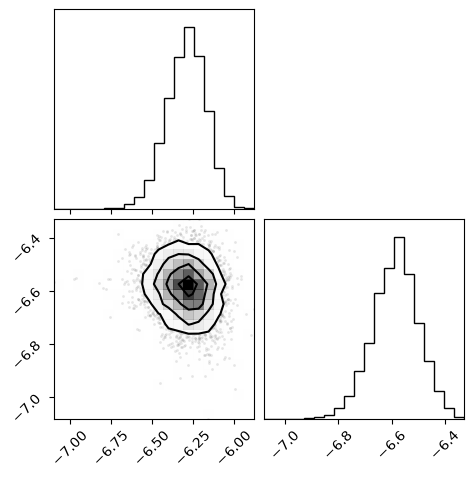

In [19]:
_=  corner.corner(df[["log10_rho[0]", "log10_rho[1]"]])

## Build a `ceffyl` KDE representation of the free spectrum

`ceffyl` refits a spectral model against a KDE of the per-frequency free-spectrum posterior
rather than the full PTA likelihood, so each refit takes seconds instead of hours.

The `log10_rho` convention transfers directly. `discovery`'s `freespectrum` returns
$10^{2\log_{10}\rho}$ as the Fourier-coefficient variance, and `ceffyl` compares its PSD models
against that same quantity via $\tfrac{1}{2}\log_{10}\rho$ — so no rescaling is needed.

This writes `ceffyl-freespec/`, which is the directory students hand to `Ceffyl.ceffyl(datadir=...)`.


In [20]:
import numpy as np
import pandas as pd
import la_forge.core as co
from ceffyl import densities

N_FREQS = 14
Tspan = ds.getspan(psrs)

coredir = Path("../ceffyl-core")
outdir = Path("../ceffyl-freespec")
coredir.mkdir(exist_ok=True)

fspec = pd.read_feather("../data/fspec-curn-sim.feather")

core = co.Core(
    chain=fspec[[f"log10_rho[{i}]" for i in range(N_FREQS)]].to_numpy(),
    params=[f"log10_rho_{i}" for i in range(N_FREQS)],
    burn=0,
    label="curn_freespec_sim",
)
core.set_rn_freqs(freqs=np.arange(1, N_FREQS + 1) / Tspan)
core.save(str(coredir / "freespec.core"))

kdes = densities.DE_factory(
    coredir=str(coredir), recursive=False, pulsar_names=["freespec"]
)
assert list(kdes.rho_labels) == [f"log10_rho_{i}" for i in range(N_FREQS)]

kdes.setup_densities(
    outdir=str(outdir),
    rho_grid=np.linspace(-9.0, -4.0, 10000),
    bandwidth="ISJ",
    kde_func="FFTKDE",
    kernel="epanechnikov",
)

libstempo not installed. PINT or libstempo are required to use par and tim files.
PINT not installed. PINT or libstempo are required to use par and tim files.


Computing densities for psr 0..


/home/dave/Dropbox/Documents/research/nanograv/talks/gw-school-2026-materials/.venv/lib/python3.12/site-packages/pandas/io/feather_format.py:123: FutureWarning: pyarrow.feather.read_feather is deprecated as of 24.0.0. Use pyarrow.ipc.open_file() / RecordBatchFileReader instead. Feather V2 is the Arrow IPC file format.
  return feather.read_feather(


removing nansfrom HDF5 file....


array([[[-35.35050621, -35.35050621, -35.35050621, ..., -35.35050621,
         -35.35050621, -35.35050621],
        [-35.35050621, -35.35050621, -35.35050621, ..., -35.35050621,
         -35.35050621, -35.35050621],
        [-35.35050621, -35.35050621, -35.35050621, ..., -35.35050621,
         -35.35050621, -35.35050621],
        ...,
        [ -0.56586422,  -0.56595293,  -0.5660874 , ..., -35.35050621,
         -35.35050621, -35.35050621],
        [ -0.41083536,  -0.41081462,  -0.41086189, ..., -35.35050621,
         -35.35050621, -35.35050621],
        [ -0.23552222,  -0.23562533,  -0.23585357, ..., -35.35050621,
         -35.35050621, -35.35050621]]], shape=(1, 14, 10000))